In [1]:
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split

from sklearn.linear_model import LinearRegression,SGDRegressor

from sklearn.preprocessing import PolynomialFeatures,StandardScaler

from sklearn.metrics import r2_score

from sklearn.pipeline import Pipeline

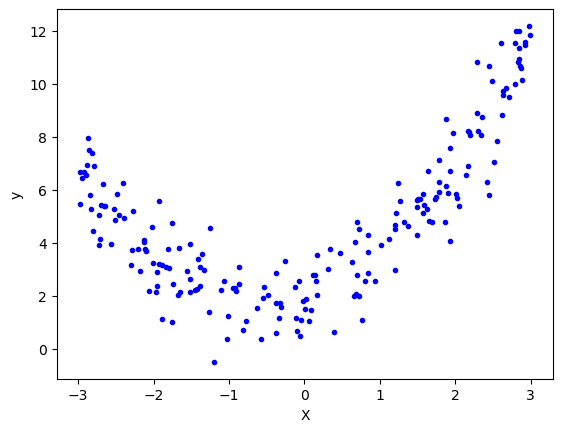

In [2]:
X = 6 * np.random.rand(200, 1) - 3
y = 0.8 * X**2 + 0.9 * X + 2 + np.random.randn(200, 1)

# y = 0.8x^2 + 0.9x + 2
plt.plot(X, y,'b.')
plt.xlabel("X")
plt.ylabel("y")
plt.show()

In [3]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
lr = LinearRegression()
lr.fit(X_train, y_train)

,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


R2 Score: 0.31748711249085193


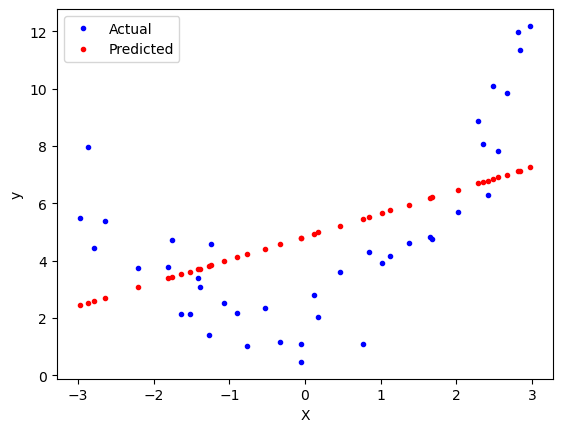

In [4]:
y_pred = lr.predict(X_test)
print("R2 Score:", r2_score(y_test, y_pred))
plt.plot(X_test, y_test,'b.', label='Actual')
plt.plot(X_test, y_pred,'r.', label='Predicted')
plt.xlabel("X")
plt.ylabel("y")
plt.legend()
plt.show()

In [5]:
poly_features = PolynomialFeatures(degree=2, include_bias=True)
X_train_poly = poly_features.fit_transform(X_train)
X_test_poly = poly_features.transform(X_test)

In [6]:
print("X_train_poly first row:", X_train_poly[0])
print("X_train first row:", X_train[0])

X_train_poly first row: [1.         2.35232368 5.53342672]
X_train first row: [2.35232368]


In [7]:
lr_poly = LinearRegression()
lr_poly.fit(X_train_poly, y_train)

,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


R2 Score (Polynomial): 0.8837984848104522


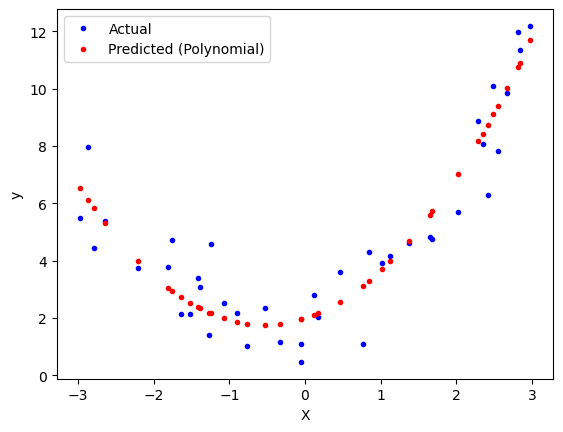

In [8]:
y_pred_poly = lr_poly.predict(X_test_poly)
print("R2 Score (Polynomial):", r2_score(y_test, y_pred_poly))
plt.plot(X_test, y_test,'b.', label='Actual')
plt.plot(X_test, y_pred_poly,'r.', label='Predicted (Polynomial)')
plt.xlabel("X")
plt.ylabel("y")
plt.legend()
plt.show()

In [9]:
def polynomial_regression(degree):
    X_new = np.linspace(-3, 3, 100).reshape(100, 1)
    X_new_poly = poly_features.transform(X_new)

    polybig_features = PolynomialFeatures(degree=degree, include_bias=False)
    std_scaler = StandardScaler()
    lin_reg = LinearRegression()
    polynomial_regression_model = Pipeline([
            ("poly_features", polybig_features),
            ("std_scaler", std_scaler),
            ("lin_reg", lin_reg),
        ])
    polynomial_regression_model.fit(X, y)
    y_newbig = polynomial_regression_model.predict(X_new)
    plt.plot(X_new, y_newbig, 'r', label="Degree " + str(degree), linewidth=2)

    plt.plot(X_train, y_train, "b.", linewidth=3, label="Training Data")
    plt.plot(X_test, y_test, "g.", linewidth=3, label="Test Data")
    plt.legend(loc="upper left")
    plt.xlabel("X")
    plt.ylabel("y")
    plt.axis([-3, 3, 0, 10])
    plt.show()

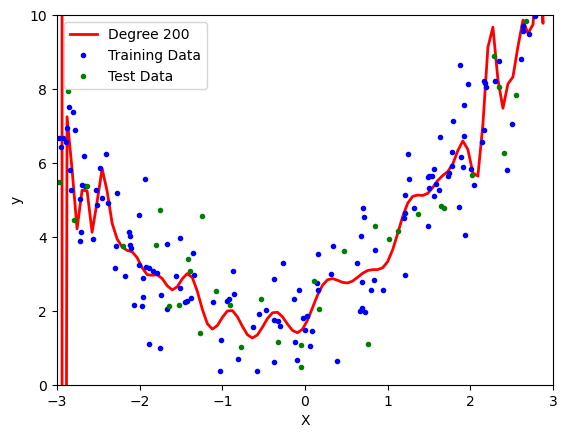

In [10]:
polynomial_regression(200)

In [11]:
poly_features.powers_

array([[0],
       [1],
       [2]], dtype=int64)

d:\CondaEnvs\placement_env\lib\site-packages\sklearn\utils\validation.py:1406: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)


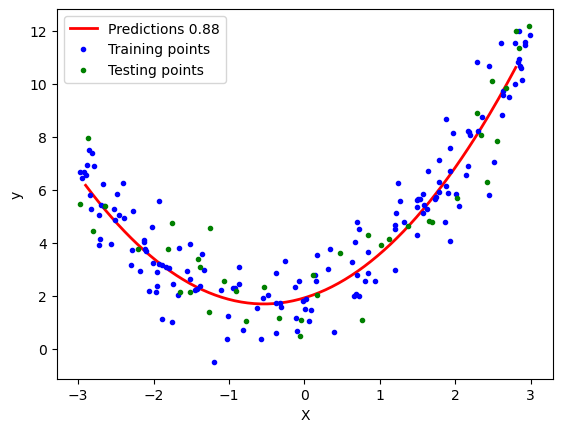

In [12]:
poly = PolynomialFeatures(degree=2)

X_train_trans = poly.fit_transform(X_train)
X_test_trans = poly.transform(X_test)

sgd = SGDRegressor(max_iter=100)
sgd.fit(X_train_trans,y_train)

X_new=np.linspace(-2.9, 2.8, 200).reshape(200, 1)
X_new_poly = poly.transform(X_new)
y_new = sgd.predict(X_new_poly)

y_pred = sgd.predict(X_test_trans)

plt.plot(X_new, y_new, "r-", linewidth=2, label="Predictions " + str(round(r2_score(y_test,y_pred),2)))
plt.plot(X_train, y_train, "b.",label='Training points')
plt.plot(X_test, y_test, "g.",label='Testing points')
plt.xlabel("X")
plt.ylabel("y")
plt.legend()
plt.show()